<a href="https://colab.research.google.com/github/eliasdengo/Python-practice-from-beginning-to-advance/blob/Eliasrepos/credit_risk_modeling_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
credit_data = pd.read_csv('/content/sample_data/german_credit_data.csv')

In [ ]:
credit_data.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [ ]:
credit_data['Age'].describe()

,Age
count,1000.000000
mean,35.546000
std,11.375469
min,19.000000
25%,27.000000
50%,33.000000
75%,42.000000
max,75.000000


In [ ]:
credit_data['Risk'].value_counts()

,count
Risk,
good,700
bad,300


In [ ]:
credit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [ ]:
credit_data.isna().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [ ]:
credit_data.duplicated().sum()

np.int64(0)

In [ ]:
credit_data.dropna(inplace=True)

In [ ]:
credit_data

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
7,7,35,male,3,rent,little,moderate,6948,36,car,good
9,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
989,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
993,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [ ]:
credit_data.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [ ]:
credit_data.drop(columns='Unnamed: 0',inplace=True)

In [ ]:
credit_data

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
7,35,male,3,rent,little,moderate,6948,36,car,good
9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
989,48,male,1,own,little,moderate,1743,24,radio/TV,good
993,30,male,3,own,little,little,3959,36,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


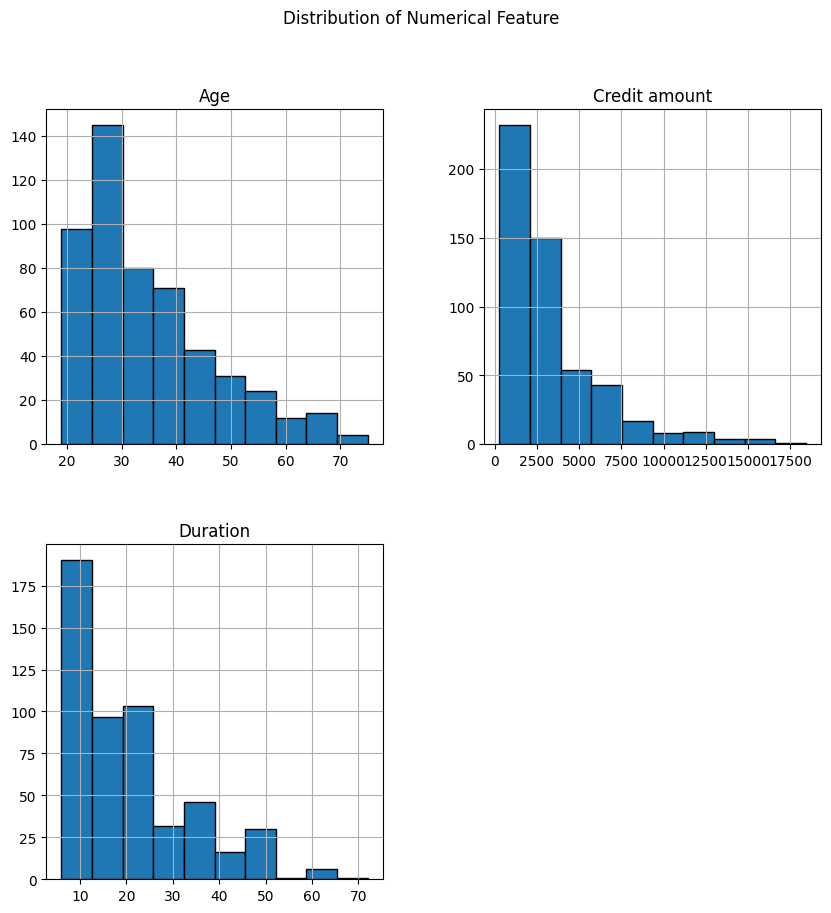

In [ ]:
credit_data[['Age','Credit amount','Duration']].hist(figsize=(10,10),edgecolor='black')
plt.suptitle('Distribution of Numerical Feature')
plt.show()

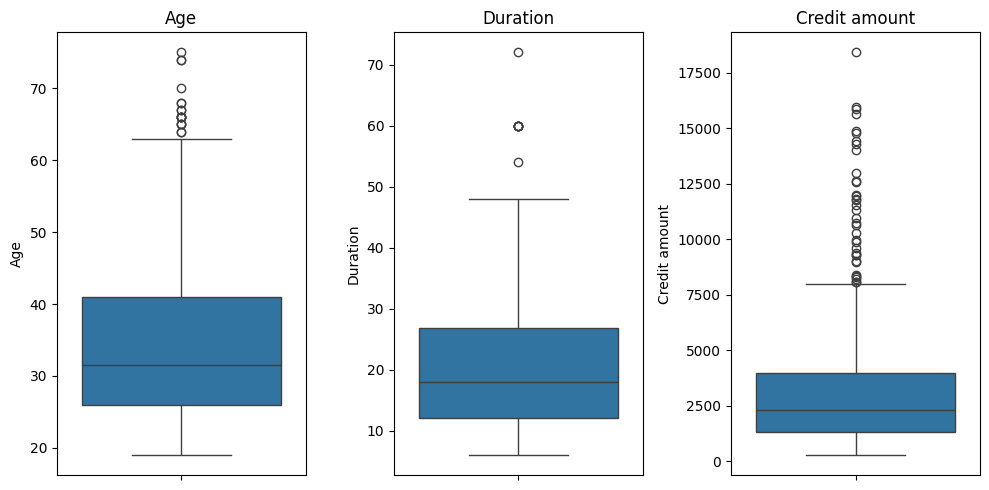

In [ ]:
plt.figure(figsize=(10,5))
for i,col in enumerate(['Age','Duration','Credit amount']):
  plt.subplot(1,3,i+1)
  sns.boxplot(credit_data[col])
  plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
credit_data.query('Age >= 60')

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
8,8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
13,13,60,male,1,own,little,little,1199,24,car,bad
29,29,63,male,2,own,little,little,6836,60,business,bad
62,62,61,male,3,free,little,moderate,1953,36,business,bad
75,75,66,male,3,free,little,little,1526,12,car,good
96,96,61,female,2,own,NaN,NaN,2012,12,education,good
123,123,63,male,2,free,little,rich,781,10,car,good
137,137,66,male,1,own,quite rich,moderate,766,12,radio/TV,bad
163,163,70,male,3,free,little,moderate,7308,10,car,good


In [ ]:
categorical_cols = ['Sex','Job','Housing','Saving accounts','Checking account','Purpose']

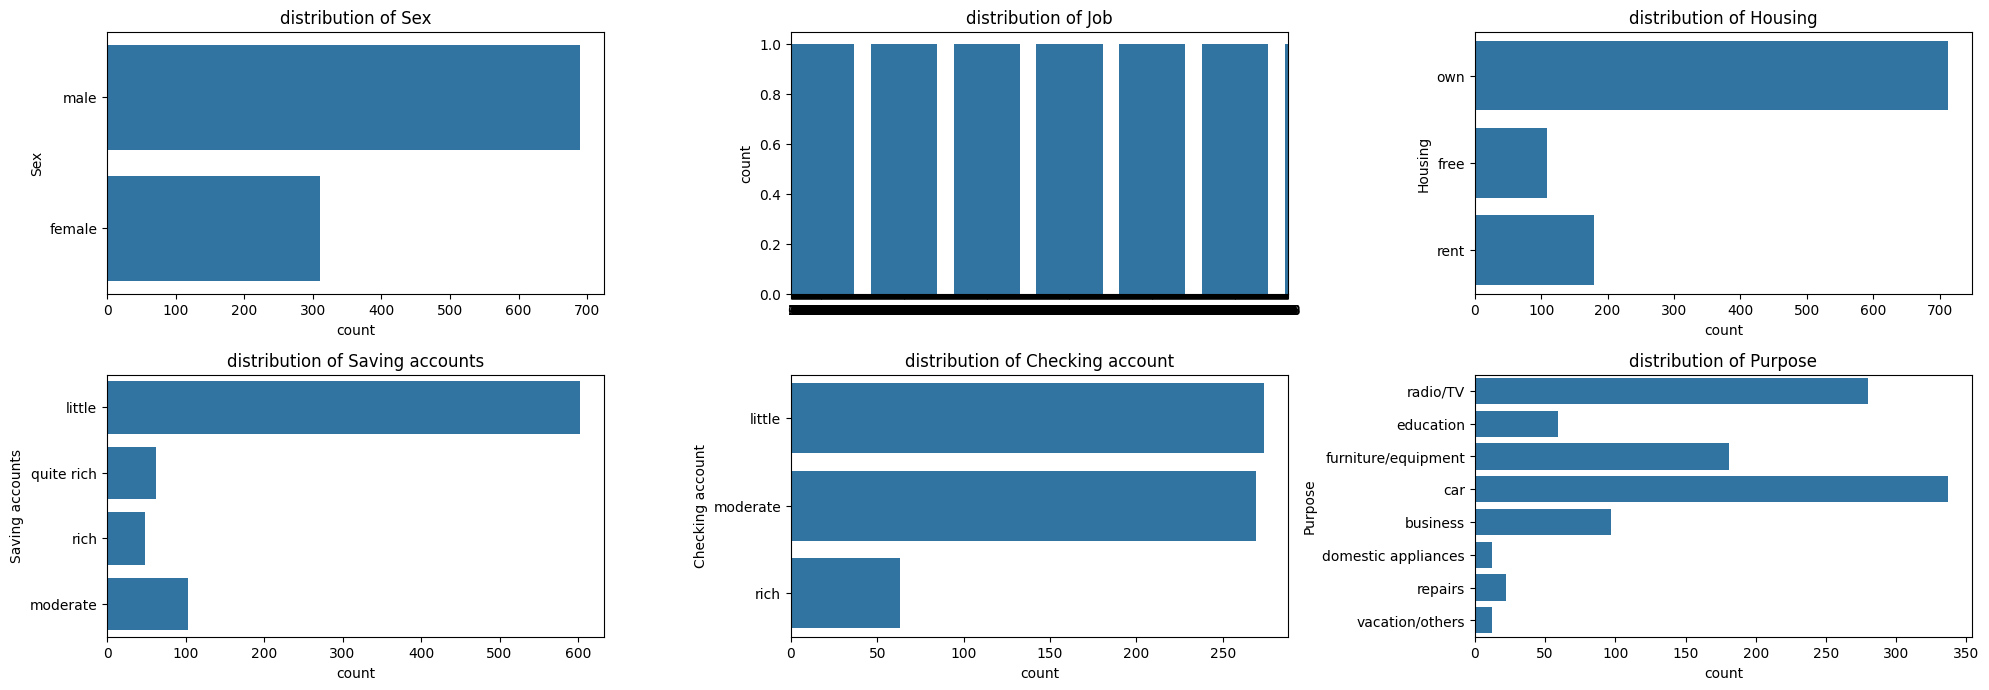

In [ ]:
plt.figure(figsize=(20,10))
for i,col in enumerate(categorical_cols):
  plt.subplot(3,3,i+1)
  sns.countplot(credit_data[col])
  plt.title(f'distribution of {col}')
plt.tight_layout()
plt.show()

In [ ]:
credit_data.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [ ]:
corr=credit_data[['Age','Job','Credit amount','Duration']].corr()

In [ ]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.015673,0.032716,-0.036136
Job,0.015673,1.000000,0.285385,0.210910
Credit amount,0.032716,0.285385,1.000000,0.624984
Duration,-0.036136,0.210910,0.624984,1.000000


<Axes: >

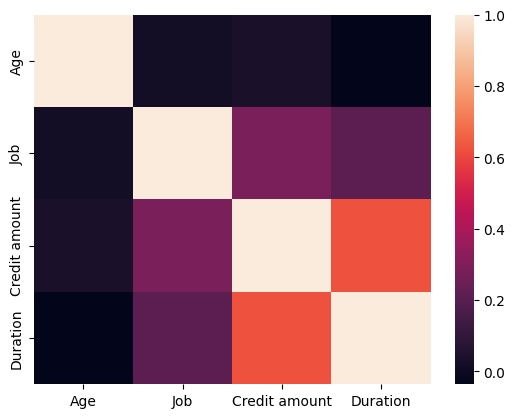

In [ ]:
sns.heatmap(corr)

In [ ]:
credit_data.groupby('Sex')['Credit amount'].mean()

,Credit amount
Sex,
female,2877.774194
male,3448.040580


In [ ]:
credit_data.groupby('Job')['Credit amount'].mean()

,Credit amount
Job,
0,2745.136364
1,2358.520000
2,3070.965079
3,5435.493243
